# Track Occupancy Classifier


In [1]:
from pathlib import Path
from fastai.vision.all import defaults, default_device
import torch
import os
import yaml

os.chdir("/Users/boser/iot/track-occupancy/cnn")

with open("../config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

default_device(torch.device("mps"))
print(f"DEVICE cuda: {defaults.use_cuda} on {defaults.cpus} cpus")

# Training / Validation data
REBUILD_DB = False
DATA_DIR = Path("../dataset/data")

# CNN parameters
TRAIN = True
THRESHOLD = 0.6
EPOCHS = 5
FREEZE_EPOCHS = 0
LEARNING_RATE = 0.0001
MODEL_NAMES = ["model", "model_int8"]

CROPPED_SIZE = cfg["CROP_SIZE_UI"]
SAMPLE_DPT = cfg["SAMPLE_DPT"]

print(
    f"Training model for {CROPPED_SIZE} x {CROPPED_SIZE} pixel images @ {SAMPLE_DPT} dpt"
)
print(f"Trained models are at {DATA_DIR} / ({'|'.join(MODEL_NAMES)}).onnx")


DEVICE cuda: mps on 12 cpus
Training model for 96 x 96 pixel images @ 20 dpt
Trained models are at ../dataset/data / (model|model_int8).onnx


In [2]:
# Prepare Database

import os
import subprocess
import pandas as pd

if REBUILD_DB:
    # Change directory
    os.chdir("/Users/boser/iot/track-occupancy/cnn")

    # Run shell command (capturing output)
    subprocess.run("cd ../dataset && pnpm run prep", shell=True, check=True)


df = pd.read_csv(DATA_DIR / "data.csv")
df.head()


,label_id,labels,is_valid,archive
0,3f2089c1-8f0d-4441-a71e-e627a466eb71,track,True,cars 0-10.r49
1,cf01ab17-75df-435f-8f55-c6ab76eb9f84,track,False,cars 0-10.r49
2,65fe03b4-d1b3-477a-9aba-883593b6e228,track,False,cars 0-10.r49
3,af9b00d4-4850-41cd-b62b-c04e48ed852e,track,False,cars 0-10.r49
4,7bfdd477-80b0-4522-b417-fb6c62048fb6,track,False,cars 0-10.r49


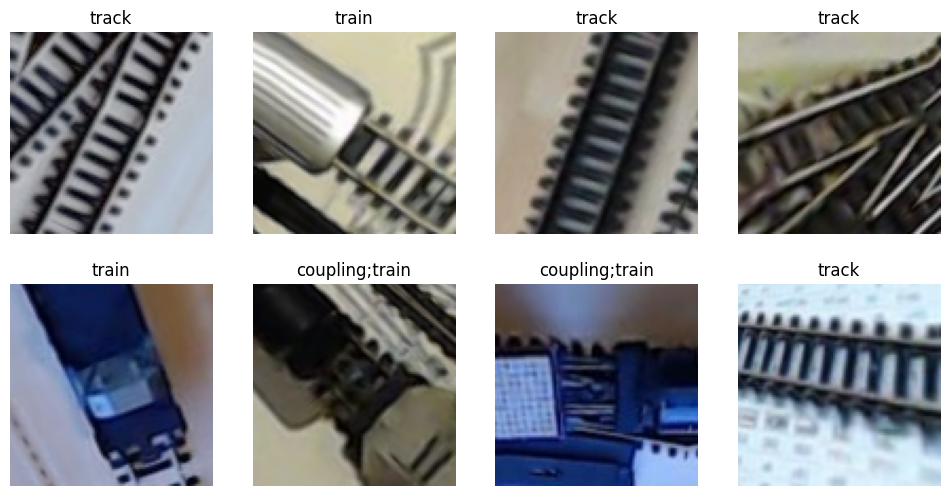

In [3]:
# Load Training/Validation Data

from fastai.vision.all import (
    DataBlock,
    ImageBlock,
    MultiCategoryBlock,
    ColSplitter,
    CropPad,
    Normalize,
    aug_transforms,
)


def get_x(r):
    return DATA_DIR / f"{r['label_id']}.jpg"


def get_y(r):
    return r["labels"].split(" ")


item_tfms = CropPad(CROPPED_SIZE)
batch_tfms = [
    *aug_transforms(
        max_rotate=80.0,
        max_lighting=0.2,
        do_flip=True,
        max_zoom=1.1,
    ),
    Normalize.from_stats(cfg["IMAGENET_MEAN"], cfg["IMAGENET_STD"]),
]

dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_x=get_x,
    get_y=get_y,
    splitter=ColSplitter("is_valid"),
    item_tfms=item_tfms,
    batch_tfms=batch_tfms,
)

dls = dblock.dataloaders(df)

dls.show_batch(nrows=2, ncols=4)


In [4]:
from fastai.vision.all import vision_learner, BCEWithLogitsLossFlat, resnet18
from fasterai.sparse.all import SparsifyCallback, large_final, one_shot
from functools import partial


def accuracy_multi(inp, targ, thresh=0.5, sigmoid=True):
    "Compute accuracy when `inp` and `targ` are the same size."
    if sigmoid:
        inp = inp.sigmoid()
    return ((inp > thresh) == targ.bool()).float().mean()


# TODO: optimization - cut off 4 fully connected layers at output to match smaller input
# (96 vs 224 pixels)

learners = [
    vision_learner(
        dls,
        resnet18,
        metrics=partial(accuracy_multi, thresh=THRESHOLD),
        loss_func=BCEWithLogitsLossFlat(),
    )
    for n in MODEL_NAMES
]

for learn, name in zip(learners, MODEL_NAMES):
    try:
        learn.load(name)
        print(f"Starting {name} from previously trained model")
    except FileNotFoundError:
        print(f"No pretrained model found for {name}")

if TRAIN:
    # Full net without pruning
    name = MODEL_NAMES[0]
    print(f"Training {name}")
    learners[0].fine_tune(EPOCHS, base_lr=LEARNING_RATE, freeze_epochs=FREEZE_EPOCHS)
    learners[0].save(name)

    # Define the SparsifyCallback
    # sparsity: percentage of weights to remove (e.g., 40)
    # granularity: 'filter' is best for CPU speedup
    # context: 'local' is usually better for accuracy
    # criteria: large_final (prune smallest weights)
    # schedule: one_shot (prune once at the end or start depending on setup)
    name = MODEL_NAMES[1]
    print(f"Training {name}")
    sp_cb = SparsifyCallback(
        sparsity=40,
        granularity="filter",
        context="local",
        criteria=large_final,
        schedule=one_shot,
    )
    learners[1].fine_tune(
        EPOCHS, base_lr=LEARNING_RATE, freeze_epochs=FREEZE_EPOCHS, cbs=sp_cb
    )
    learners[1].save(name)


Starting model from previously trained model
Starting model_int8 from previously trained model
Training model


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.000090,0.005644,0.996296,00:01
1,0.000047,0.004393,0.996296,00:01
2,0.000032,0.010699,0.996296,00:01
3,0.000023,0.007425,0.996296,00:01
4,0.000040,0.008297,0.996296,00:01


Training model_int8
Sparsifying filter until a sparsity of 40%
Final Sparsity: 0.00%

Sparsity Report:
--------------------------------------------------------------------------------
Layer                          Type            Params     Zeros      Sparsity  
--------------------------------------------------------------------------------
0.0                            Conv2d          9,408      3,528         37.50%
0.4.0.conv1                    Conv2d          36,864     13,824        37.50%
0.4.0.conv2                    Conv2d          36,864     13,824        37.50%
0.4.1.conv1                    Conv2d          36,864     13,824        37.50%
0.4.1.conv2                    Conv2d          36,864     13,824        37.50%
0.5.0.conv1                    Conv2d          73,728     28,800        39.06%
0.5.0.conv2                    Conv2d          147,456    57,600        39.06%
0.5.0.downsample.0             Conv2d          8,192      3,200         39.06%
0.5.1.conv1            

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.007589,0.034158,0.990741,00:01
1,0.003476,0.035197,0.988889,00:01
2,0.003367,0.037216,0.990741,00:01
3,0.002259,0.036281,0.992593,00:01
4,0.002188,0.036870,0.992593,00:01


Sparsity at the end of epoch 0: 0.00%
Sparsity at the end of epoch 1: 0.00%
Sparsity at the end of epoch 2: 40.00%
Sparsity at the end of epoch 3: 40.00%
Sparsity at the end of epoch 4: 40.00%
Final Sparsity: 40.00%

Sparsity Report:
--------------------------------------------------------------------------------
Layer                          Type            Params     Zeros      Sparsity  
--------------------------------------------------------------------------------
0.0                            Conv2d          9,408      3,528         37.50%
0.4.0.conv1                    Conv2d          36,864     13,824        37.50%
0.4.0.conv2                    Conv2d          36,864     13,824        37.50%
0.4.1.conv1                    Conv2d          36,864     13,824        37.50%
0.4.1.conv2                    Conv2d          36,864     13,824        37.50%
0.5.0.conv1                    Conv2d          73,728     28,800        39.06%
0.5.0.conv2                    Conv2d          147

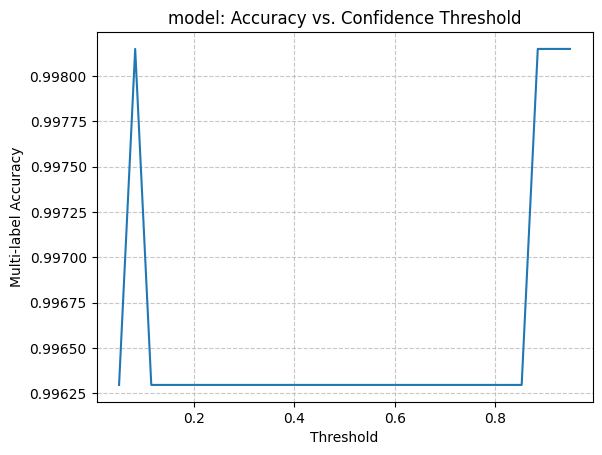

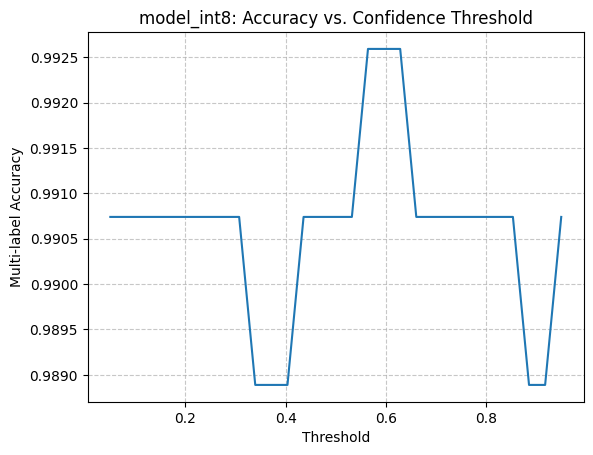

In [5]:
import torch
import matplotlib.pyplot as plt

for learn, name in zip(learners, MODEL_NAMES):
    learn.metrics = partial(accuracy_multi, thresh=0.1)
    learn.validate()

    preds, targs = learn.get_preds()
    accuracy_multi(preds, targs, thresh=0.9, sigmoid=False)

    xs = torch.linspace(0.05, 0.95, 29)
    accs = [accuracy_multi(preds, targs, thresh=i, sigmoid=False) for i in xs]
    plt.plot(xs, accs)

    # Adding descriptive labels
    plt.title(f"{name}: Accuracy vs. Confidence Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Multi-label Accuracy")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()

Top Losses for model


,target,predicted,probabilities,loss
0,track,train,"tensor([1.6296e-06, 9.6993e-02, 8.7405e-01])",1.4683374166488647
1,train,train,"tensor([5.2279e-02, 1.9223e-07, 1.0000e+00])",0.01789844036102295
2,train,train,"tensor([8.1362e-06, 4.4679e-03, 9.9343e-01])",0.0036930739879608154
3,train,train,"tensor([9.8560e-03, 2.5813e-08, 1.0000e+00])",0.0033016204833984375
4,train,train,"tensor([4.6089e-04, 4.8626e-07, 1.0000e+00])",0.00015385945152956992
5,train,train,"tensor([3.3313e-05, 3.2429e-08, 1.0000e+00])",1.1126200661237817e-05


Top Losses for model_int8


,target,predicted,probabilities,loss
0,track,train,"tensor([3.3256e-04, 1.6924e-03, 9.9955e-01])",4.699738025665283
1,train,coupling;train,"tensor([9.3310e-01, 6.5112e-06, 1.0000e+00])",0.9015178680419922
2,track,train,"tensor([1.3613e-04, 3.1188e-01, 5.5227e-01])",0.656278669834137
3,train,train,"tensor([1.4940e-04, 4.2146e-01, 6.5318e-01])",0.3244371712207794
4,coupling;train,coupling;train,"tensor([8.8449e-01, 3.5652e-06, 9.9999e-01])",0.04091927409172058
5,coupling;train,coupling;train,"tensor([9.8897e-01, 2.4435e-06, 1.0000e+00])",0.0036975748371332884


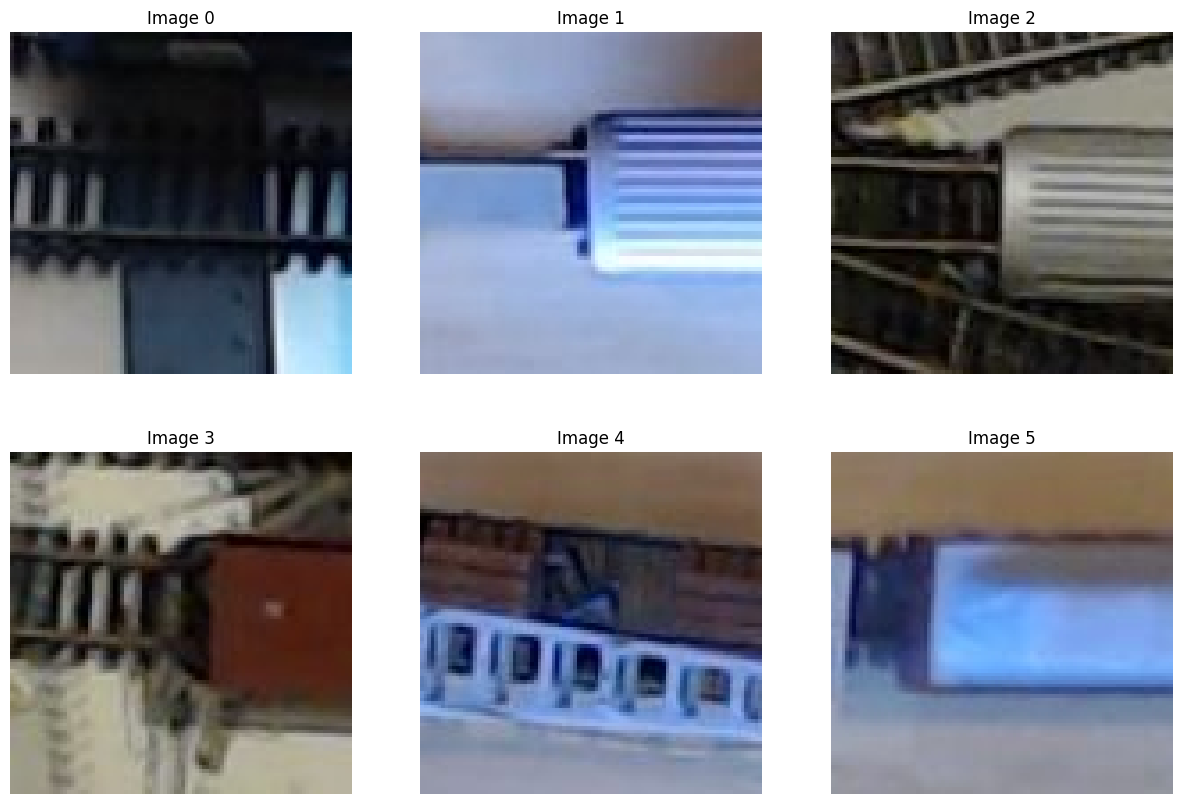

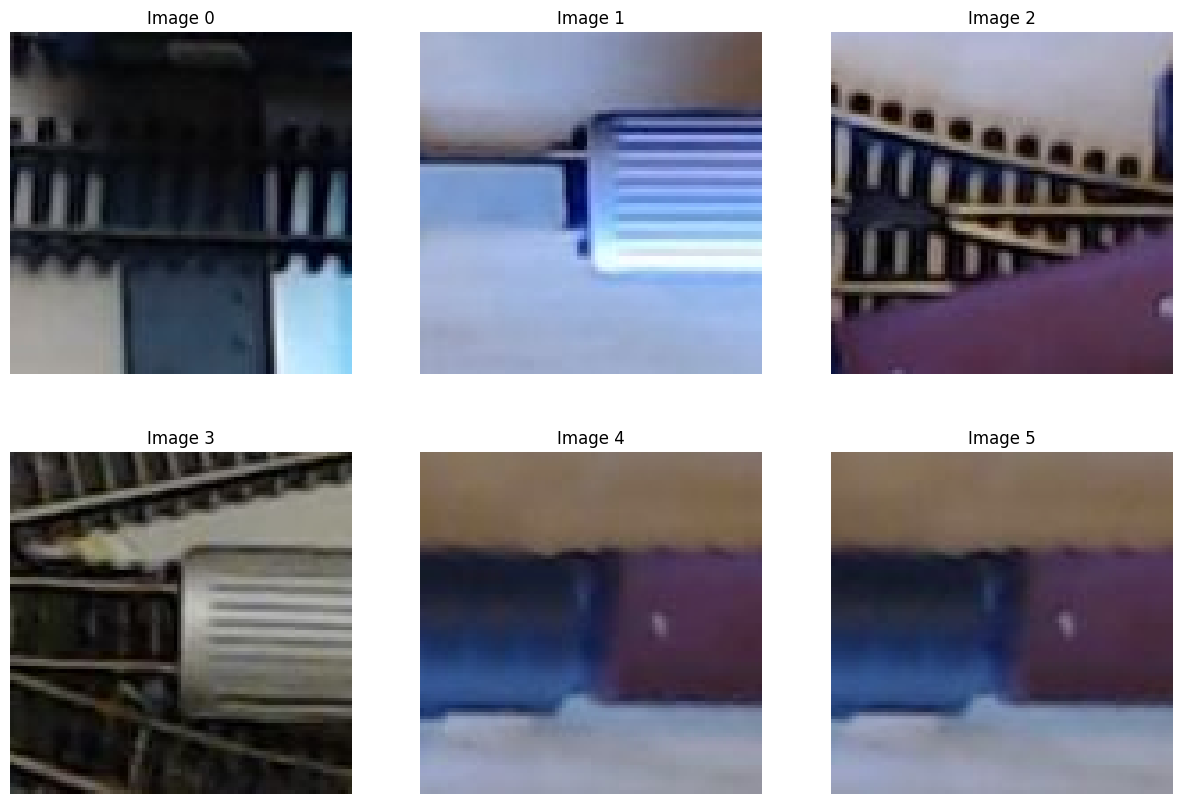

In [6]:
from fastai.vision.all import ClassificationInterpretation

for learn, name in zip(learners, MODEL_NAMES):
    interp = ClassificationInterpretation.from_learner(learn)

    # Makes no sense for multi-label problem!
    # interp.plot_confusion_matrix()

    print(f"Top Losses for {name}")
    interp.plot_top_losses(6, figsize=(15, 10))


model: Found 1 misclassified samples out of 180.
Index: 178 | File: 69c2538b-0cae-4f9a-8bb4-f025cad2ab35
  Actual:    ['track']
  Predicted: ['train']
--------------------


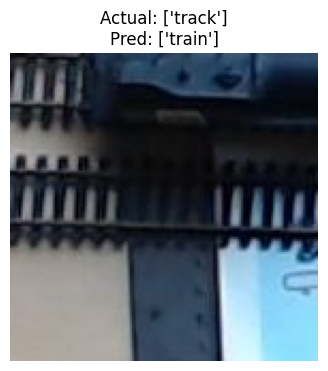

model_int8: Found 3 misclassified samples out of 180.
Index: 37 | File: 5607032a-1816-468b-a098-8fce90b28e08
  Actual:    ['track']
  Predicted: []
--------------------


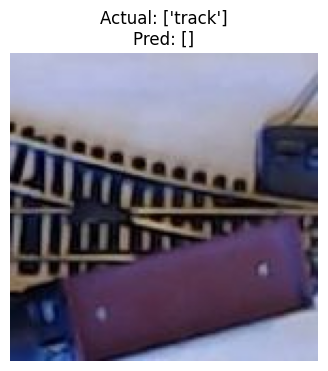

Index: 63 | File: a4141316-91e7-42c0-8edf-d6d1e6468506
  Actual:    ['train']
  Predicted: ['coupling', 'train']
--------------------


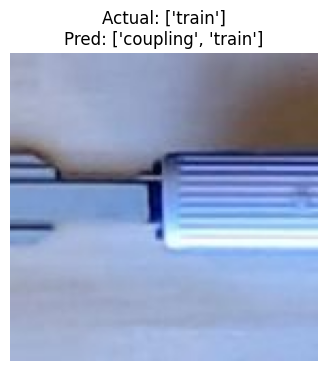

Index: 178 | File: 69c2538b-0cae-4f9a-8bb4-f025cad2ab35
  Actual:    ['track']
  Predicted: ['train']
--------------------


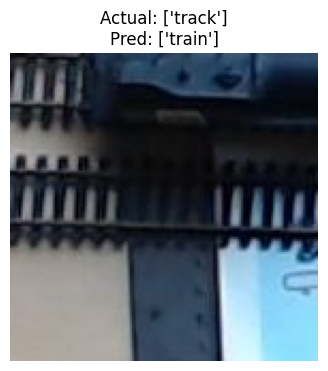

In [7]:
from fastai.vision.all import PILImage, show_image

for learn, name in zip(learners, MODEL_NAMES):
    # 1. Get predictions for the entire validation set (or dls.train for the whole thing)
    preds, targs = learn.get_preds(dl=dls.valid)

    # 2. Convert predictions to boolean (using your chosen threshold)
    thresh = THRESHOLD
    pred_bools = preds > thresh

    # 3. Find which ones don't match the targets exactly
    # (all(dim=1) ensures every single label in the multi-label set must match)
    is_error = ~(pred_bools == targs.bool()).all(dim=1)
    error_indices = torch.where(is_error)[0]
    print(
        f"{name}: Found {len(error_indices)} misclassified samples out of {len(targs)}."
    )

    # 4. Display the errors
    vocab = dls.vocab
    for idx in error_indices:
        # Get the actual labels and predicted labels
        actual = [vocab[i] for i, val in enumerate(targs[idx]) if val == 1]
        predicted = [vocab[i] for i, val in enumerate(pred_bools[idx]) if val]

        # Get the filename (assuming the order in dls.valid matches your items)
        # Fastai stores the original items in dl.items
        fn = dls.valid.items.iloc[idx.item()]["label_id"]

        print(f"Index: {idx.item()} | File: {fn}")
        print(f"  Actual:    {actual}")
        print(f"  Predicted: {predicted}")
        print("-" * 20)

        fn = dls.valid.items.iloc[idx.item()]["label_id"]

        # Load path
        img_path = DATA_DIR / f"{fn}.jpg"
        img = PILImage.create(img_path)

        # Show image with labels
        ax = show_image(img, title=f"Actual: {actual}\nPred: {predicted}")
        plt.show()  # Forces the notebook to show the image before continuing the loop

In [8]:
# Export model

import torch
import json

for learn, name in zip(learners, MODEL_NAMES):
    # 1. Prepare model
    model = learn.model.cpu()
    model.eval()

    # 2. Create dummy input
    dummy_input = torch.randn(1, 3, CROPPED_SIZE, CROPPED_SIZE)

    # 3. TRACE the model first (this forces the legacy ONNX path)
    traced_model = torch.jit.trace(model, dummy_input)

    # 4. Export the TRACED model
    onnx_path = f"models/{name}.onnx"
    torch.onnx.export(
        traced_model,  # Use traced_model here
        dummy_input,
        onnx_path,
        export_params=True,
        do_constant_folding=True,
        input_names=["input"],
        output_names=["output"],
        opset_version=18,
        dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
        dynamo=False,
    )

# Write config.json
with open("models/config.json", "w") as f:
    json.dump(
        {
            "labels": list(dls.vocab),
            "dpt": SAMPLE_DPT,
            "crop_size": CROPPED_SIZE,
            "mean": cfg["IMAGENET_MEAN"],
            "std": cfg["IMAGENET_STD"],
            "threshold": THRESHOLD,
        },
        f,
        indent=2,
    )


/var/folders/ym/p6gv14tn4w32d2m3zj3l_rkm0000gn/T/ipykernel_57206/2195401466.py:19: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
/Users/boser/iot/track-occupancy/cnn/.venv/lib/python3.12/site-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1510: UserWarning: no signature found for builtin <built-in method __call__ of pybind11_builtins.pybind11_detail_function_record_v1_system_libcpp_abi1 object at 0x10876e9d0>, skipping _decide_input_format
  args = _decide_input_format(model, args)


In [9]:
# Quantize to int8

from onnxruntime.quantization import (
    quantize_static,
    CalibrationDataReader,
    QuantType,
    QuantFormat,
    CalibrationMethod,
    quant_pre_process,
)
import numpy as np
from PIL import Image
import os


# 1. Define a Calibration Data Reader
# This feeds a few real images to the quantizer so it can see the data distribution
class TrackCalibrationDataReader(CalibrationDataReader):
    def __init__(self, image_folder, batch_size=16):
        self.image_paths = list(Path(image_folder).glob("*.jpg"))[
            :256
        ]  # Use images for calibration
        self.preprocess_flag = True
        self.enum_data = None

    def get_next(self):
        if self.enum_data is None:
            # Load and preprocess images (match your training preprocessing)
            # This should result in a numpy array of shape [Batch, 3, CROPPED_SIZE, CROPPED_SIZE]
            data_list = []
            for path in self.image_paths:
                img = (
                    Image.open(path).convert("RGB").resize((CROPPED_SIZE, CROPPED_SIZE))
                )
                arr = np.array(img).astype(np.float32) / 255.0
                # Normalize (matching fastai/imagenet defaults)
                arr = (arr - cfg["IMAGENET_MEAN"]) / cfg["IMAGENET_STD"]
                data_list.append(arr.transpose(2, 0, 1))  # HWC to CHW

            self.enum_data = iter(
                [{"input": np.stack(data_list).astype(np.float32)}]
            )  # 'input' must match ONNX input name
        return next(self.enum_data, None)


# 2. Run the Quantization
name = MODEL_NAMES[1]

model_fp32 = "models/sparse_fp32.onnx"
model_int8 = f"models/{name}.onnx"

os.rename(model_int8, model_fp32)

quant_pre_process(model_fp32, model_fp32, skip_optimization=False)
dr = TrackCalibrationDataReader("../dataset/data")  # Point to your training data
quantize_static(
    model_input=model_fp32,
    model_output=model_int8,
    calibration_data_reader=dr,
    quant_format=QuantFormat.QDQ,  # Best for modern CPUs
    activation_type=QuantType.QUInt8,
    weight_type=QuantType.QInt8,
    calibrate_method=CalibrationMethod.Entropy,
)
print(f"Quantized model saved to {name}.onnx")

os.remove(model_fp32)

Finding optimal threshold for each tensor using 'entropy' algorithm ...
Number of tensors : 56
Number of histogram bins : 128 (The number may increase depends on the data it collects)
Number of quantized bins : 128
Quantized model saved to model_int8.onnx


In [10]:
# Convert to ORT

from onnxruntime.tools.convert_onnx_models_to_ort import (
    OptimizationStyle,
    convert_onnx_models_to_ort,
)

for name in MODEL_NAMES:
    try:
        convert_onnx_models_to_ort(
            Path(f"models/{name}.onnx"), optimization_styles=[OptimizationStyle.Fixed]
        )
    except Exception as e:
        print(f"Failed to convert to ORT: {e}")


2026-05-15 08:55:32,434 ort_format_model.utils [INFO] - Created config in /Users/boser/iot/track-occupancy/cnn/models/model.required_operators.config
2026-05-15 08:55:32,466 ort_format_model.utils [INFO] - Created config in /Users/boser/iot/track-occupancy/cnn/models/model_int8.required_operators.config


Converting models with optimization style 'Fixed' and level 'all'
Converting optimized ONNX model /Users/boser/iot/track-occupancy/cnn/models/model.onnx to ORT format model /Users/boser/iot/track-occupancy/cnn/models/model.ort
Converted 1/1 models successfully.
Generating config file from ORT format models with optimization style 'Fixed' and level 'all'
Converting models with optimization style 'Fixed' and level 'all'
Converting optimized ONNX model /Users/boser/iot/track-occupancy/cnn/models/model_int8.onnx to ORT format model /Users/boser/iot/track-occupancy/cnn/models/model_int8.ort
Converted 1/1 models successfully.
Generating config file from ORT format models with optimization style 'Fixed' and level 'all'


In [11]:
# Compare ONNX and Fastai models on validation set...

import onnxruntime as ort
import numpy as np

for learn, name in zip(learners, MODEL_NAMES):
    # 1. Load the ONNX session
    # 'cpu' is default; use 'TensorrtExecutionProvider' or 'CoreMLExecutionProvider' for hardware accel
    # if name == "model_int8": name = "sparse_fp32"
    ort_session = ort.InferenceSession(f"models/{name}.onnx")

    # 2. Get the input name (usually "input" as defined in your export)
    input_name = ort_session.get_inputs()[0].name

    all_onnx_preds = []
    all_fastai_preds = []
    all_targets = []

    with torch.no_grad():
        for x, y in dls.valid:
            # Move to CPU to match model
            x_cpu = x.cpu()

            # ONNX Prediction
            x_numpy = x_cpu.numpy()
            batch_onnx = ort_session.run(None, {input_name: x_numpy})[0]

            # Fastai (PyTorch) Prediction
            batch_fastai = learn.model(x_cpu).cpu().numpy()

            all_onnx_preds.append(batch_onnx)
            all_fastai_preds.append(batch_fastai)
            all_targets.append(y.cpu().numpy())

    all_onnx_preds = np.concatenate(all_onnx_preds)
    all_fastai_preds = np.concatenate(all_fastai_preds)
    all_targets = np.concatenate(all_targets)

    # Compare
    max_diff = np.abs(all_onnx_preds - all_fastai_preds).max()
    avg_diff = np.abs(all_onnx_preds - all_fastai_preds).mean()
    matches = np.allclose(all_onnx_preds, all_fastai_preds, atol=1e-5)

    print(f"Comparison for {name}: ")
    print(f" - Max difference: {max_diff:.2e}")
    print(f" - Avg difference: {avg_diff:.2e}")
    print(f" - Matches (atol=1e-5): {matches}")
    print(
        "(for quantized models a large discrepancy is expected since the model is compared to the fp32 version)"
    )
    print()


Comparison for model: 
 - Max difference: 1.49e-04
 - Avg difference: 1.46e-05
 - Matches (atol=1e-5): True
(for quantized models a large discrepancy is expected since the model is compared to the fp32 version)

Comparison for model_int8: 
 - Max difference: 9.68e+00
 - Avg difference: 7.87e-01
 - Matches (atol=1e-5): False
(for quantized models a large discrepancy is expected since the model is compared to the fp32 version)

